In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')


In [3]:
df= pd.read_csv('better data.csv')
print(df)


             ID                                     Name           Area  \
0        ADHI_1         VINA NORD (BINI) a PONT DE BEREM    1566.639483   
1       ADHI_10         SANAGA a SAKBAYEME (SONGMBENGUE)  127871.199700   
2      ADHI_100                      KOUILOU a KAKAMOEKA   64602.869040   
3     ADHI_1000                           DARGOL at TERA    2612.515260   
4     ADHI_1001                    SIRBA at GARBE-KOUROU   40287.678410   
...         ...                                      ...            ...   
1461   ADHI_995              MAPUTO at WESTOE (27632207)     507.011330   
1462   ADHI_996    BONNIE BROOK at BROADHOLMS (27632208)     103.324895   
1463   ADHI_997  NGWEMPISI at BUSHMANS SPRUIT (27632204)     451.578496   
1464   ADHI_998      SWARTWATER at ZWARTWATER (27632206)     166.725785   
1465   ADHI_999                        GOROUOL at DOLBEL    7837.465873   

      Mean_altitude  Maximum_altitude  Minimum_altitude  \
0            1111.0              1241   

In [4]:
df_clean = df.dropna(subset=df.columns[3:26])  # Drop rows where X or y has NaN
X = df_clean.iloc[:, 2:24].values
y = df_clean.iloc[:, 25].values

In [5]:
print(X.shape)  # Prints (rows, columns)


(1463, 22)


In [6]:
y

array([  98.45, 6590.  , 2660.5 , ...,   14.55,    8.32,  132.  ])

In [7]:
X

array([[1.56663948e+03, 1.11100000e+03, 1.24100000e+03, ...,
        7.61451324e-01, 2.45101331e+02, 1.73388052e+00],
       [1.27871200e+05, 8.50000000e+02, 2.19300000e+03, ...,
        6.57690299e-01, 3.12068774e+03, 2.44355420e+00],
       [6.46028690e+04, 4.14000000e+02, 8.51000000e+02, ...,
        6.46288853e-01, 2.22364181e+03, 2.44961007e+00],
       ...,
       [4.51578496e+02, 1.49600000e+03, 1.61000000e+03, ...,
        8.62185942e-01, 1.48294079e+02, 1.95395796e+00],
       [1.66725785e+02, 1.33700000e+03, 1.40900000e+03, ...,
        1.05135831e+00, 8.93473240e+01, 1.93748431e+00],
       [7.83746587e+03, 2.88100000e+02, 3.48000000e+02, ...,
        1.36310508e-01, 5.72464999e+02, 1.81058592e+00]])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [138]:
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define the parameter space for hyperparameter tuning
param_space = {
    'n_estimators': Integer(10, 1000),  # More flexible range
    'max_depth': Integer(1, 100),
    'max_features': Real(0.1, 1.0, prior='uniform'),
    'min_samples_leaf': Integer(1, 20),
    'min_samples_split': Integer(2, 20)
}

# Define the Random Forest Regressor
reg = RandomForestRegressor(random_state=42)

# Define the scoring function (negative MSE since BayesSearchCV maximizes the score)
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Create a BayesSearchCV object for hyperparameter tuning
opt = BayesSearchCV(
    reg,
    param_space,
    scoring=scoring,  # Use negative MSE as the metric
    cv=10,
    n_iter=100,  # Number of iterations for Bayesian Optimization
    n_jobs=-1,
    random_state=42
)

# Fit the model to training data
opt.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters:", opt.best_params_)

# Access the best model
best_rf = opt.best_estimator_

# Evaluate the best model on the test set using RMSE
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


Best hyperparameters: OrderedDict([('max_depth', 100), ('max_features', 0.1), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 10)])
Test RMSE: 1071.1565126009232


In [139]:
from joblib import dump

# Save the trained model to a file

# Later, load it back with:
# from joblib import load
# loaded_model = load('random_forest_model.joblib')# Save the model
dump(best_rf, 'RF.joblib')

from joblib import load
import numpy as np

model = load('RF.joblib')



In [140]:
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Define the parameter space for XGBoost hyperparameter tuning
param_space = {
    'n_estimators': Integer(10, 1000),
    'max_depth': Integer(1, 20),  # XGBoost typically uses shallower trees
    'learning_rate': Real(0.001, 0.3, prior='log-uniform'),  # Also called eta
    'subsample': Real(0.5, 1.0, prior='uniform'),
    'colsample_bytree': Real(0.5, 1.0, prior='uniform'),
    'gamma': Real(0, 5, prior='uniform'),  # Minimum loss reduction to make a split
    'reg_alpha': Real(0, 10, prior='uniform'),  # L1 regularization
    'reg_lambda': Real(0, 10, prior='uniform')  # L2 regularization
}

# Define the XGBoost Regressor
reg = XGBRegressor(random_state=42, n_jobs=-1)

# Define the scoring function (negative MSE since BayesSearchCV maximizes the score)
scoring = make_scorer(mean_squared_error, greater_is_better=False)

# Create a BayesSearchCV object for hyperparameter tuning
opt = BayesSearchCV(
    reg,
    param_space,
    scoring=scoring,
    cv=10,
    n_iter=100,  # Number of iterations for Bayesian Optimization
    n_jobs=-1,   # Note: XGBoost already uses n_jobs in the estimator
    random_state=42
)

# Fit the model to training data
opt.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters:", opt.best_params_)

# Access the best model
best_xgb = opt.best_estimator_

# Evaluate the best model on the test set using RMSE
y_pred = best_xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)

Best hyperparameters: OrderedDict([('colsample_bytree', 1.0), ('gamma', 4.482380294869095), ('learning_rate', 0.04494259269103703), ('max_depth', 1), ('n_estimators', 846), ('reg_alpha', 10.0), ('reg_lambda', 0.0), ('subsample', 0.5)])
Test RMSE: 996.1533893178915


In [141]:
from joblib import dump

# Save the best XGBoost model
dump(best_xgb, 'XGB.joblib')

# dump(best_xgb, 'optimized_xgboost.joblib')

['XGB.joblib']

In [7]:
from sklearn.svm import SVR
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from joblib import dump

# Define SVM parameter space
from skopt.space import Real, Categorical



param_space = {
    'C': Real(1e-3, 500, prior='log-uniform'),              # Broader range for regularization
    'gamma': Real(1e-6, 10, prior='log-uniform'),           # More flexibility on the kernel coefficient
    'epsilon': Real(1e-4, 1.0, prior='log-uniform'),        # SVR epsilon-insensitive zone
    'kernel': Categorical(['rbf']),      # Trying additional kernels
    'degree': Integer(2, 5),                                # For polynomial kernel (if used)
    'shrinking': Categorical([True, False])                 # Optional: use shrinking heuristic or not
}


# Initialize SVM
svm = SVR()

# Bayesian optimization
opt = BayesSearchCV(
    svm,
    param_space,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

opt.fit(X_train, y_train)

# Best model
best_svm = opt.best_estimator_
print("Best SVM params:", opt.best_params_)

# Save model
dump(best_svm, 'SVM.joblib')

Best SVM params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', False)])


['SVM.joblib']

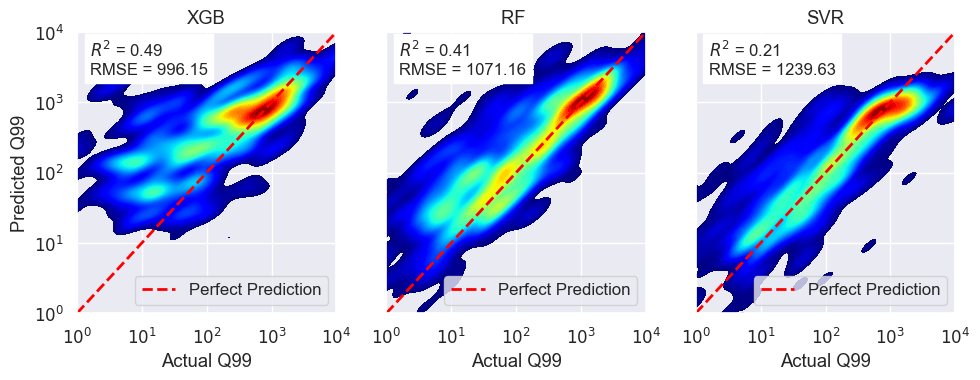

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm
import joblib

sns.set_theme(style="darkgrid", font_scale=1.1)

models = [
    ("XGB", "XGB.joblib"),
    ("RF ", "RF.joblib"),
    ("SVR", "SVM.joblib")
]

x_min, x_max = 1e0, 1e4
y_min, y_max = x_min, x_max

def clean_data(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if isinstance(y_true, np.ma.MaskedArray):
        y_true = y_true.filled(np.nan)
    if isinstance(y_pred, np.ma.MaskedArray):
        y_pred = y_pred.filled(np.nan)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return y_true[mask], y_pred[mask]

fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

for ax, (title, model_path) in zip(axes, models):
    model = joblib.load(model_path)
    
    y_pred = model.predict(X_test)
    y_test_clean, y_pred_clean = clean_data(y_test, y_pred)
    
    r2 = r2_score(y_test_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
    
    log_y_true = np.log10(y_test_clean)
    log_y_pred = np.log10(y_pred_clean)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.5,
        thresh=0.05,
        levels=100,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=2, label='Perfect Prediction')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(y_min), np.log10(y_max))
    
    ax.set_xlabel('Actual Q99')
    ax.set_ylabel('Predicted Q99')
    ax.set_title(title)
    
    ax.text(0.05, 0.85,
            f'$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}',
            transform=ax.transAxes,
            fontsize=12,
            bbox=dict(facecolor='white', alpha=1))
    
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('comparison.tif', dpi=300, bbox_inches='tight')
plt.show()


In [219]:
X.shape

(1463, 22)

# k means clustering k=2

In [278]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

param_space = {
    'n_estimators': Integer(50, 1000),
    'max_depth': Integer(3, 12),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'reg_alpha': Real(0, 10),
    'reg_lambda': Real(0, 10)
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining XGBoost model for Cluster {cluster+1}/{K}")
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    xgb = XGBRegressor(random_state=42, n_jobs=-1)
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        xgb,
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training XGBoost model for Cluster 1/2
Cluster 0 RMSE: 238.4628

Training XGBoost model for Cluster 2/2
Cluster 1 RMSE: 986.1346

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 238.4628
- Best params: OrderedDict([('colsample_bytree', 0.6065687826719878), ('gamma', 1.7685699160505197), ('learning_rate', 0.02221876239806809), ('max_depth', 3), ('n_estimators', 1000), ('reg_alpha', 5.875338832309436), ('reg_lambda', 10.0), ('subsample', 0.9798260418706827)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 986.1346
- Best params: OrderedDict([('colsample_bytree', 0.8159294873624924), ('gamma', 0.8915916689222096), ('learning_rate', 0.01822326912033851), ('max_depth', 3), ('n_estimators', 202), ('reg_alpha', 8.739408179676095), ('reg_lambda', 1.2629683246652665), ('subsample', 0.8826787954367874)])



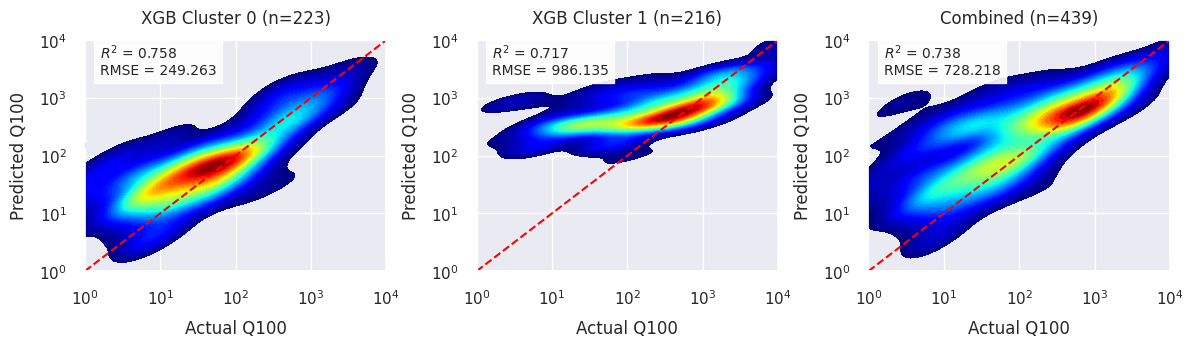

In [279]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme(style="darkgrid", font_scale=1)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.05,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q100', labelpad=8)
    ax.set_ylabel('Predicted Q100', labelpad=8)

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, K+1, wspace=0.3)

all_y_test = []
all_y_pred = []

for cluster in range(K):
    ax = fig.add_subplot(gs[0, cluster])
    if cluster not in results:
        ax.axis('off')
        continue
        
    test_mask = (test_clusters == cluster)
    y_test_cl = y_test[test_mask]
    y_pred_cl = results[cluster]['model'].predict(X_test[test_mask])
    
    all_y_test.append(y_test_cl)
    all_y_pred.append(y_pred_cl)
    
    create_cluster_plot(y_test_cl, y_pred_cl, 
                       f'XGB Cluster {cluster} (n={len(y_test_cl)})', 
                       ax)

ax_combined = fig.add_subplot(gs[0, -1])
y_test_all = np.concatenate(all_y_test)
y_pred_all = np.concatenate(all_y_pred)
create_cluster_plot(y_test_all, y_pred_all, 
                   f'Combined (n={len(y_test_all)})', 
                   ax_combined)

plt.tight_layout()
#plt.savefig('XGB k=2.tif', dpi=300, bbox_inches='tight')

plt.show()

In [280]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'xgb_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

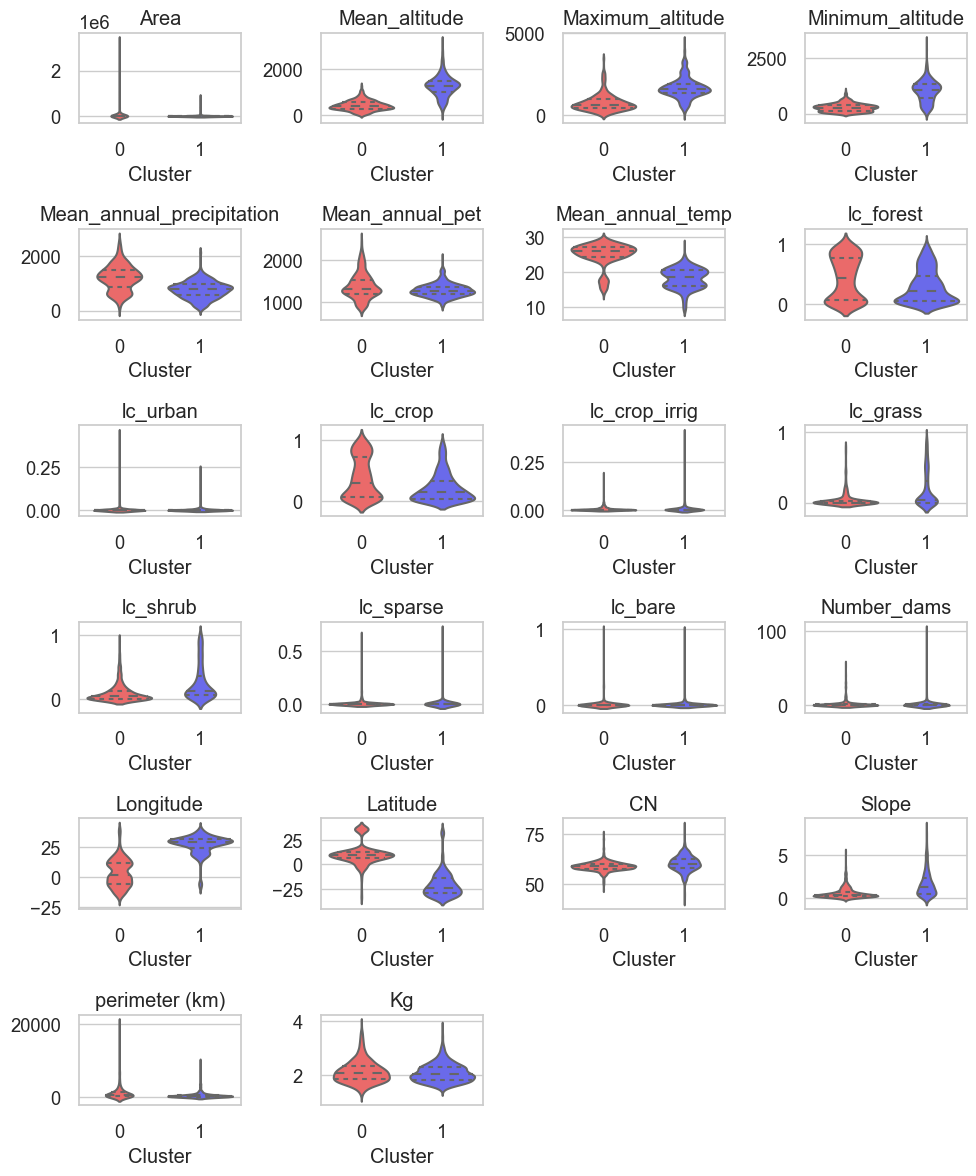

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
sns.set_theme(style="whitegrid", font_scale=1.2)

df = pd.read_csv("better data.csv")

features = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
    'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
    'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
    'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
    'CN', 'Slope', 'perimeter (km)', 'Kg'
]

df_clean = df.dropna(subset=features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])
palette = sns.color_palette("seismic_r", K)  # One color per cluster

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clean['Cluster'] = clusters

for i in range(K):
    cluster_df = df_clean[df_clean['Cluster'] == i]
    cluster_df.to_csv(f"cluster_{i}.csv", index=False)

num_features = len(features)
cols = 4  
rows = int(np.ceil(num_features / cols))

plt.figure(figsize=(2.5 * cols, 2 * rows))
for i, feature in enumerate(features):
    plt.subplot(rows, cols, i + 1)
    sns.violinplot(data=df_clean, x='Cluster', y=feature, palette=palette, inner='quartile')
    plt.title(feature)
    plt.xlabel('Cluster')
    plt.ylabel('')

plt.tight_layout()
plt.show()


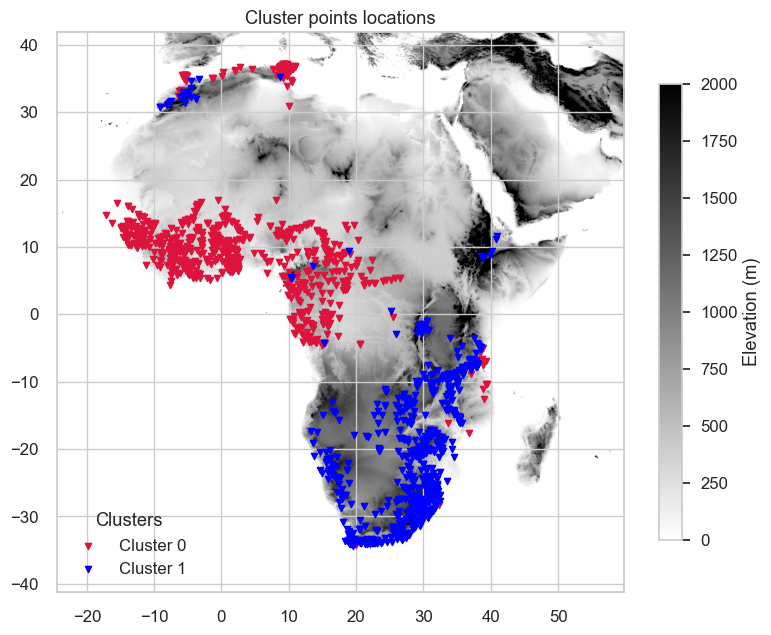

In [185]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", font_scale=1.1)

shapefile_path = 'maghreb.shp'
elevation_tif_path = 'elevation final.tif'
num_clusters = 2  

gdf_outline = gpd.read_file(shapefile_path)

with rasterio.open(elevation_tif_path) as src:
    elevation_bounds = src.bounds
    elevation_crs = src.crs

palette = sns.color_palette("Paired", num_clusters)
palette = ["crimson", "blue", "red"]  # Or pick any 3 hex or named colors

elevation_min = 0     # Set your minimum elevation value
elevation_max = 2000  # Set your maximum elevation value
elevation_cmap = 'binary'  # Colormap: 'terrain', 'viridis', 'gist_earth', etc.

fig, ax = plt.subplots(figsize=(8, 8))

with rasterio.open(elevation_tif_path) as src:
    img = show(
        src, 
        ax=ax, 
        cmap=elevation_cmap,
        vmin=elevation_min,
        vmax=elevation_max,
        alpha=1
    )

cbar = plt.colorbar(ax.get_images()[0], ax=ax, shrink=0.6)
cbar.set_label('Elevation (m)')

gdf_outline.boundary.plot(ax=ax, edgecolor='none', linewidth=0.5)

for cluster_id in range(num_clusters):
    cluster_path = f"cluster_{cluster_id}.csv"
    if os.path.exists(cluster_path):
        df_cluster = pd.read_csv(cluster_path)
        gdf_cluster = gpd.GeoDataFrame(
            df_cluster,
            geometry=gpd.points_from_xy(df_cluster['Longitude'], df_cluster['Latitude']),
            crs="EPSG:4326"
        )
        gdf_cluster = gdf_cluster.to_crs(elevation_crs)

        gdf_cluster.plot(
            ax=ax,
            color=palette[cluster_id],
            markersize=20,
            marker='v',
            label=f"Cluster {cluster_id}"
        )
    else:
        print(f"Warning: {cluster_path} not found.")

ax.set_xlim([elevation_bounds.left, elevation_bounds.right])
ax.set_ylim([elevation_bounds.bottom, elevation_bounds.top])

ax.legend(title="Clusters", loc="lower left")
ax.set_title("Cluster points locations")
plt.tight_layout()
plt.savefig('cluster_locations.png', dpi=300, bbox_inches='tight')
plt.show()

# RF

In [245]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Changed import
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical  # Added Categorical
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

# Data scaling remains the same
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# Updated parameter space for Random Forest
param_space = {
    'n_estimators': Integer(50, 1000),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 20),
    'max_features': Real(0.1, 1.0),
    'max_samples': Real(0.5, 1.0)
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining Random Forest model for Cluster {cluster+1}/{K}")  # Updated text
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    # Initialize Random Forest instead of XGBoost
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        rf,  # Changed estimator
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training Random Forest model for Cluster 1/2
Cluster 0 RMSE: 247.5173

Training Random Forest model for Cluster 2/2
Cluster 1 RMSE: 1047.7766

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 247.5173
- Best params: OrderedDict([('max_depth', 17), ('max_features', 0.3469982473162821), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 1000)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 1047.7766
- Best params: OrderedDict([('max_depth', 18), ('max_features', 1.0), ('max_samples', 0.9829560216588367), ('min_samples_leaf', 3), ('min_samples_split', 2), ('n_estimators', 1000)])



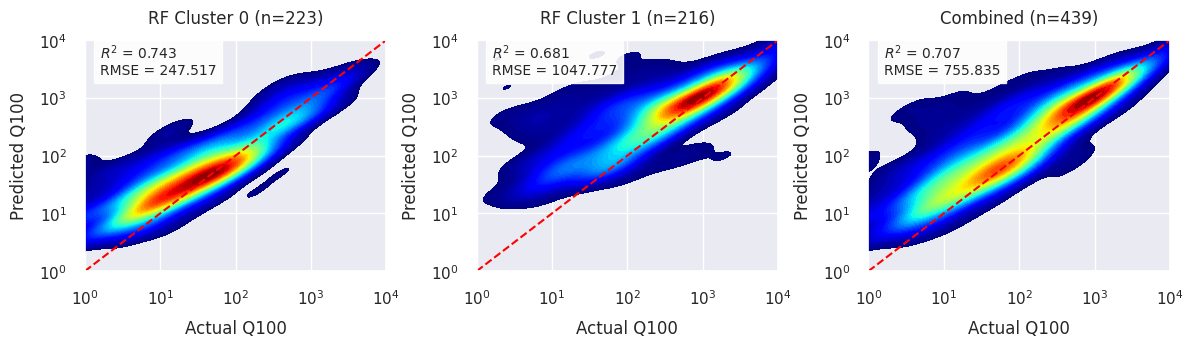

In [246]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm

sns.set_theme(style="darkgrid", font_scale=1)
plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.05,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q100', labelpad=8)
    ax.set_ylabel('Predicted Q100', labelpad=8)

fig = plt.figure(figsize=(14, 3))
gs = fig.add_gridspec(1, K+1, wspace=0.3)

all_y_test = []
all_y_pred = []

for cluster in range(K):
    ax = fig.add_subplot(gs[0, cluster])
    if cluster not in results:
        ax.axis('off')
        continue
        
    test_mask = (test_clusters == cluster)
    y_test_cl = y_test[test_mask]
    y_pred_cl = results[cluster]['model'].predict(X_test[test_mask])
    
    all_y_test.append(y_test_cl)
    all_y_pred.append(y_pred_cl)
    
    create_cluster_plot(y_test_cl, y_pred_cl, 
                       f'RF Cluster {cluster} (n={len(y_test_cl)})', 
                       ax)

ax_combined = fig.add_subplot(gs[0, -1])
y_test_all = np.concatenate(all_y_test)
y_pred_all = np.concatenate(all_y_pred)
create_cluster_plot(y_test_all, y_pred_all, 
                   f'Combined (n={len(y_test_all)})', 
                   ax_combined)

plt.tight_layout()
plt.savefig('RF k=2.tif', dpi=300, bbox_inches='tight')

plt.show()

In [247]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'rf_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

# SVM

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR  # Changed import
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical  # Added Categorical
from sklearn.metrics import mean_squared_error, make_scorer
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

train_clusters = kmeans.predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

# Updated parameter space for SVR
param_space = {
    'C': Real(1e-3, 500, prior='log-uniform'),              # Broader range for regularization
    'gamma': Real(1e-6, 10, prior='log-uniform'),           # More flexibility on the kernel coefficient
    'epsilon': Real(1e-4, 1.0, prior='log-uniform'),        # SVR epsilon-insensitive zone
    'kernel': Categorical(['rbf']),      # Trying additional kernels
    'degree': Integer(2, 5),                                # For polynomial kernel (if used)
    'shrinking': Categorical([True, False])                 # Optional: use shrinking heuristic or not
}

cluster_models = {}
results = {}

for cluster in range(K):
    print(f"\nTraining SVR model for Cluster {cluster+1}/{K}")
    
    train_mask = (train_clusters == cluster)
    test_mask = (test_clusters == cluster)
    
    X_train_cl = X_train[train_mask]
    y_train_cl = y_train[train_mask]
    X_test_cl = X_test[test_mask]
    y_test_cl = y_test[test_mask]
    
    if len(X_train_cl) == 0:
        print(f"Skipping cluster {cluster} - no training samples")
        continue
    
    svr = SVR()  # Changed model
    scoring = make_scorer(mean_squared_error, greater_is_better=False)
    
    opt = BayesSearchCV(
        svr,  # Changed estimator
        param_space,
        n_iter=50,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        random_state=42
    )
    
    opt.fit(X_train_cl, y_train_cl)
    
    cluster_models[cluster] = opt.best_estimator_
    
    if len(X_test_cl) > 0:
        y_pred = opt.best_estimator_.predict(X_test_cl)
        rmse = np.sqrt(mean_squared_error(y_test_cl, y_pred))
        results[cluster] = {
            'train_samples': len(X_train_cl),
            'test_samples': len(X_test_cl),
            'rmse': rmse,
            'best_params': opt.best_params_,
            'model': opt.best_estimator_
        }
        print(f"Cluster {cluster} RMSE: {rmse:.4f}")
    else:
        print(f"Cluster {cluster} has no test samples")

print("\nCluster Performance Summary:")
for cluster, res in results.items():
    print(f"Cluster {cluster}:")
    print(f"- Train samples: {res['train_samples']}")
    print(f"- Test samples: {res['test_samples']}")
    print(f"- Test RMSE: {res['rmse']:.4f}")
    print(f"- Best params: {res['best_params']}\n")


Training SVR model for Cluster 1/2
Cluster 0 RMSE: 395.0006

Training SVR model for Cluster 2/2
Cluster 1 RMSE: 1661.2348

Cluster Performance Summary:
Cluster 0:
- Train samples: 496
- Test samples: 223
- Test RMSE: 395.0006
- Best params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', False)])

Cluster 1:
- Train samples: 528
- Test samples: 216
- Test RMSE: 1661.2348
- Best params: OrderedDict([('C', 499.99999999999994), ('degree', 2), ('epsilon', 1.0), ('gamma', 1e-06), ('kernel', 'rbf'), ('shrinking', True)])



In [11]:
from joblib import dump

dump(scaler, 'cluster_scaler.joblib')       
dump(kmeans, 'cluster_kmeans.joblib')        

for cluster, model in cluster_models.items():
    dump(model, f'svm_cluster_{cluster}.joblib')

cluster_info = {
    'n_clusters': K,
    'train_distribution': np.bincount(train_clusters),
    'test_distribution': np.bincount(test_clusters)
}
dump(cluster_info, 'cluster_info.joblib')

['cluster_info.joblib']

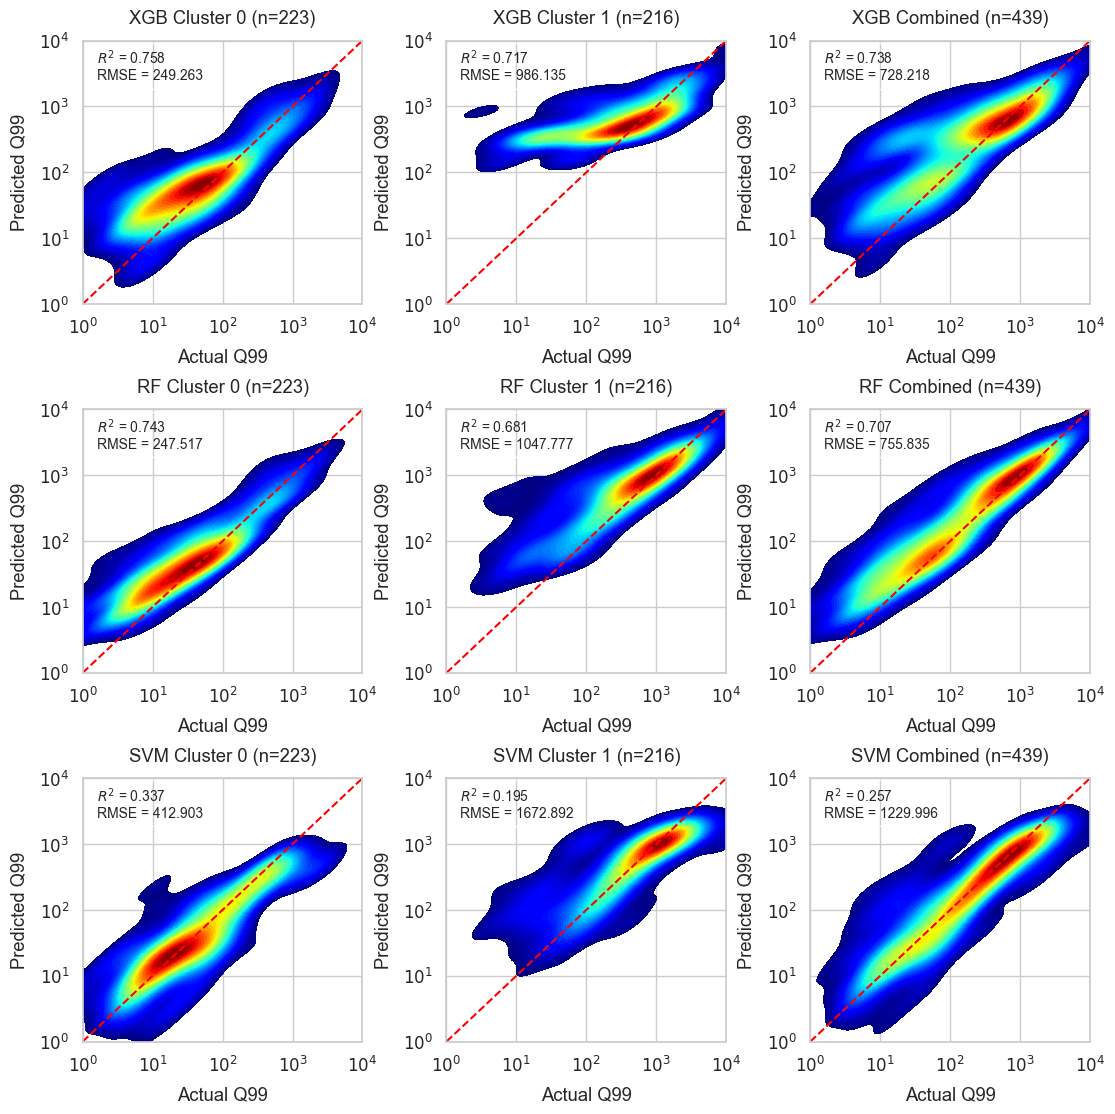

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
import matplotlib.cm as cm
import joblib

sns.set_theme(style="whitegrid", font_scale=1.1)
#plt.rcParams['font.family'] = 'DejaVu Sans'  # Match font style

def clean_data(y_true, y_pred):
    # Implement your data cleaning logic here if needed
    mask = (y_true > 0) & (y_pred > 0)
    return y_true[mask], y_pred[mask]

def create_cluster_plot(y_true, y_pred, title, ax, x_min=1e0, x_max=1e4):
    """Create density plot for a single cluster"""
    y_true, y_pred = clean_data(y_true, y_pred)
    
    if len(y_true) == 0:
        ax.axis('off')
        return
    
    log_y_true = np.log10(y_true)
    log_y_pred = np.log10(y_pred)
    
    sns.kdeplot(
        x=log_y_true,
        y=log_y_pred,
        fill=True,
        cmap=cm.get_cmap('jet'),
        bw_adjust=0.8,
        thresh=0.1,
        levels=50,
        ax=ax
    )
    
    log_bins = np.linspace(np.log10(x_min), np.log10(x_max), 100)
    ax.plot(log_bins, log_bins, '--', color='red', linewidth=1.5, label='1:1 line')
    
    ax.set_xticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_xticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    ax.set_yticks(np.log10([1e0, 1e1, 1e2, 1e3, 1e4]))
    ax.set_yticklabels([r"$10^0$", r"$10^1$", r"$10^2$", r"$10^3$", r"$10^4$"])
    
    ax.set_xlim(np.log10(x_min), np.log10(x_max))
    ax.set_ylim(np.log10(x_min), np.log10(x_max))
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.text(0.05, 0.85, 
            f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}', 
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor='none', alpha=0.9))
    
    ax.set_title(title, pad=12)
    ax.set_xlabel('Actual Q99', labelpad=8)
    ax.set_ylabel('Predicted Q99', labelpad=8)

# Assuming you have X_test and y_test defined
models = ['XGB','RF', 'SVM']
K = 2  # Number of clusters for all models

fig = plt.figure(figsize=(13, 13))  # Adjusted for 3 rows
gs = fig.add_gridspec(len(models), K+1, wspace=0.3, hspace=0.4)

for row_idx, model_name in enumerate(models):
    # Load clustering artifacts
    scaler = joblib.load(f"{model_name}/cluster_scaler.joblib")
    kmeans = joblib.load(f"{model_name}/cluster_kmeans.joblib")
    
    # Load cluster models
    cluster_models = {}
    for cluster in range(K):
        cluster_models[cluster] = joblib.load(f"{model_name}/{model_name.lower()}_cluster_{cluster}.joblib")
    
    # Transform test data and predict clusters
    X_test_scaled = scaler.transform(X_test)
    test_clusters = kmeans.predict(X_test_scaled)
    
    all_y_test = []
    all_y_pred = []
    
    # Create cluster plots
    for cluster in range(K):
        ax = fig.add_subplot(gs[row_idx, cluster])
        test_mask = (test_clusters == cluster)
        y_test_cl = y_test[test_mask]
        
        if len(y_test_cl) == 0:
            ax.axis('off')
            continue
            
        y_pred_cl = cluster_models[cluster].predict(X_test[test_mask])
        
        all_y_test.append(y_test_cl)
        all_y_pred.append(y_pred_cl)
        
        create_cluster_plot(y_test_cl, y_pred_cl,
                           f'{model_name} Cluster {cluster} (n={len(y_test_cl)})',
                           ax)
    
    # Create combined plot for the row
    ax_combined = fig.add_subplot(gs[row_idx, K])
    if len(all_y_test) > 0:
        y_test_all = np.concatenate(all_y_test)
        y_pred_all = np.concatenate(all_y_pred)
        create_cluster_plot(y_test_all, y_pred_all,
                           f'{model_name} Combined (n={len(y_test_all)})',
                           ax_combined)
    else:
        ax_combined.axis('off')

plt.tight_layout()
plt.savefig('all_models_comparison.tif', dpi=300, bbox_inches='tight')
plt.show()

## clustering without geographic distribution

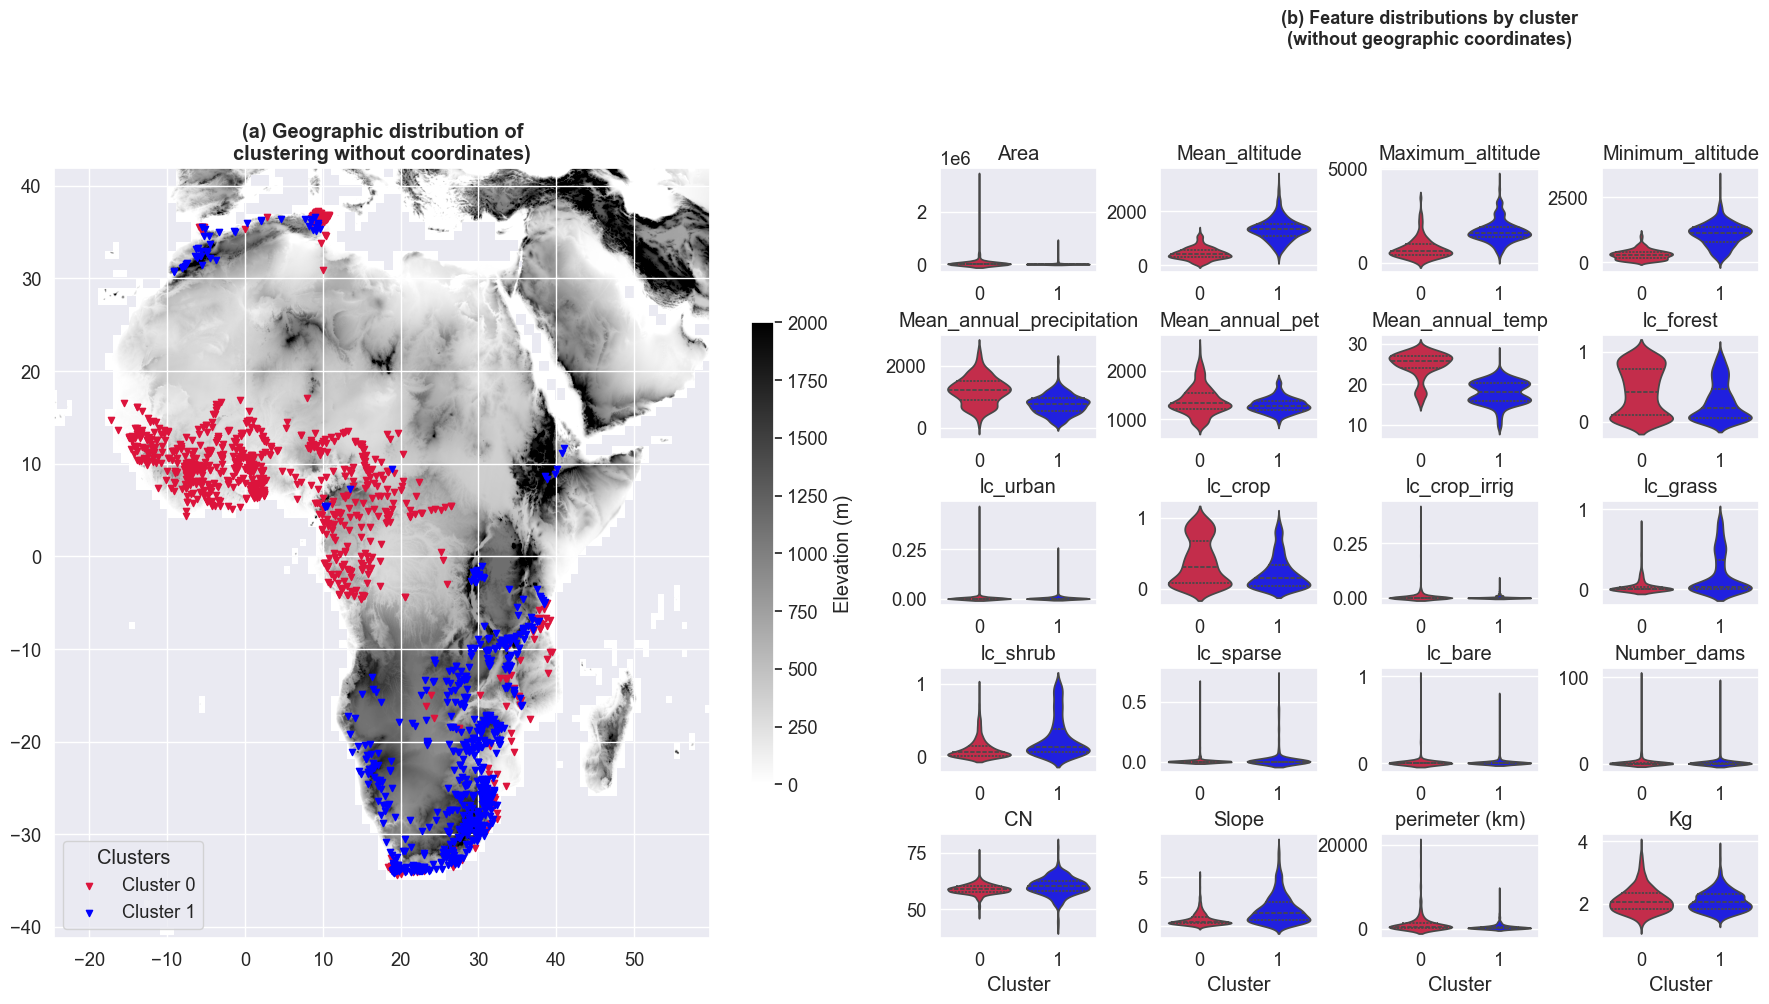

In [15]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="darkgrid", font_scale=1.2)

# ── Settings ──────────────────────────────────────────────
shapefile_path     = 'maghreb.shp'
elevation_tif_path = 'elevation final.tif'
num_clusters       = 2
palette            = ["crimson", "blue"]
elevation_min, elevation_max = 0, 2000
elevation_cmap     = 'binary'

# ── Clustering WITHOUT coordinates ────────────────────────
features_no_coords = ['Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
    'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
    'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
    'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams',
    'CN', 'Slope', 'perimeter (km)', 'Kg'
]

df = pd.read_csv("better data.csv").dropna(subset=features_no_coords)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[features_no_coords])
kmeans   = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df['Cluster'] = df['Cluster'].map({0: 1, 1: 0})

for i in range(num_clusters):
    df[df['Cluster'] == i].to_csv(f"cluster_nocoords_{i}.csv", index=False)

# ── Figure (1 × 2) — equal width panels ───────────────────
num_features = len(features_no_coords)
cols = 4
rows = int(np.ceil(num_features / cols))
last_row_start = (rows - 1) * cols

fig = plt.figure(figsize=(22, rows * 2))
gs_outer = fig.add_gridspec(1, 2, wspace=0.08)

# ── LEFT: Geographic map ──────────────────────────────────
ax_map = fig.add_subplot(gs_outer[0])

gdf_outline = gpd.read_file(shapefile_path)
with rasterio.open(elevation_tif_path) as src:
    elevation_bounds = src.bounds
    elevation_crs    = src.crs
    show(src, ax=ax_map, cmap=elevation_cmap,
         vmin=elevation_min, vmax=elevation_max, alpha=1)

cbar = plt.colorbar(ax_map.get_images()[0], ax=ax_map, shrink=0.6)
cbar.set_label('Elevation (m)')
gdf_outline.boundary.plot(ax=ax_map, edgecolor='none', linewidth=0.5)

for cluster_id in range(num_clusters):
    path = f"cluster_nocoords_{cluster_id}.csv"
    if os.path.exists(path):
        df_c = pd.read_csv(path)
        gdf_c = gpd.GeoDataFrame(
            df_c,
            geometry=gpd.points_from_xy(df_c['Longitude'], df_c['Latitude']),
            crs="EPSG:4326"
        ).to_crs(elevation_crs)
        gdf_c.plot(ax=ax_map, color=palette[cluster_id],
                   markersize=20, marker='v', label=f"Cluster {cluster_id}")

ax_map.set_xlim([elevation_bounds.left,  elevation_bounds.right])
ax_map.set_ylim([elevation_bounds.bottom, elevation_bounds.top])
ax_map.set_aspect('auto')
ax_map.legend(title="Clusters", loc="lower left")
ax_map.set_title("(a) Geographic distribution of\nclustering without coordinates)", fontweight='bold')

# ── RIGHT: Violin grid ────────────────────────────────────
gs_right = gs_outer[1].subgridspec(rows, cols, hspace=0.6, wspace=0.4)

for i, feature in enumerate(features_no_coords):
    r, c = divmod(i, cols)
    sub = fig.add_subplot(gs_right[r, c])
    sns.violinplot(data=df, x='Cluster', y=feature,
                   palette=palette, inner='quartile', ax=sub)
    sub.set_title(feature)
    sub.set_ylabel('')
    if i >= last_row_start:
        sub.set_xlabel('Cluster')
    else:
        sub.set_xlabel('')

# Title for the violin panel
fig.text(0.75, 1.0, "(b) Feature distributions by cluster\n(without geographic coordinates)",
         ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.savefig('cluster_nocoords_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\MJS\AppData\Local\Temp\ipykernel_9452\3268124983.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_features, palette=palette, ax=ax)


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\MJS\AppData\Local\Temp\ipykernel_9452\3268124983.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_features, palette=palette, ax=ax)


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\MJS\AppData\Local\Temp\ipykernel_9452\3268124983.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_features, palette=palette, ax=ax)


  0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\MJS\AppData\Local\Temp\ipykernel_9452\3268124983.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_features, palette=palette, ax=ax)
C:\Users\MJS\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:160: UserWarning: [00:59:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnin

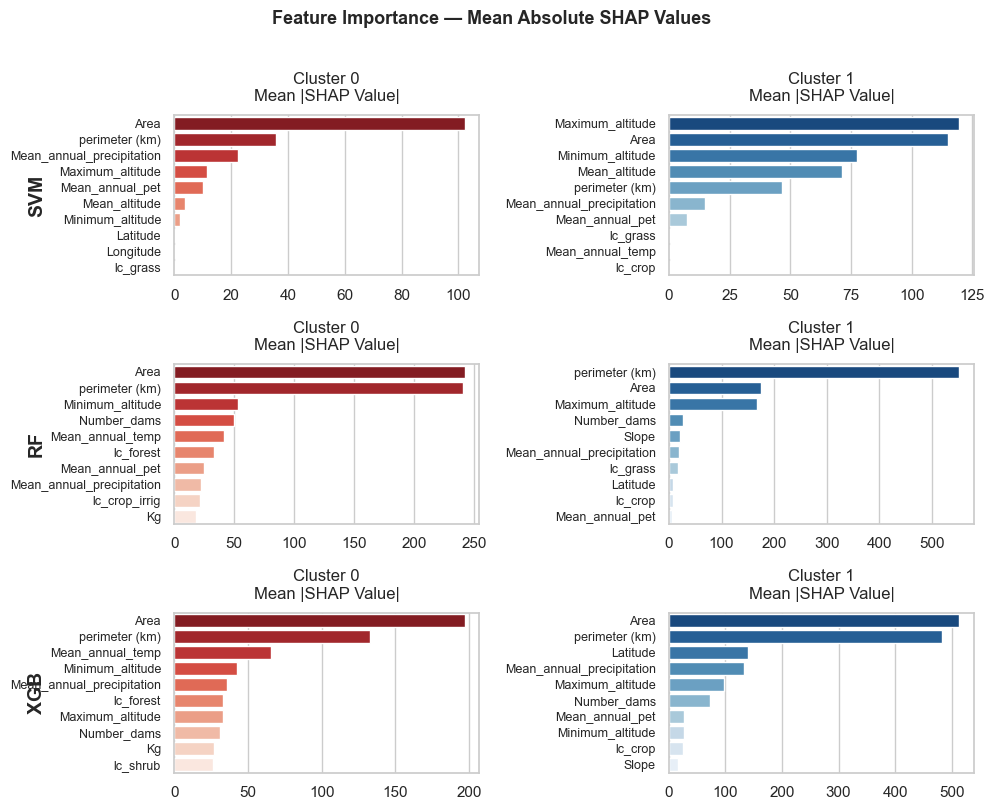

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12

feature_names = [
    'Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
    'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
    'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
    'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
    'CN', 'Slope', 'perimeter (km)', 'Kg'
]

models           = [('SVM', 'Reds_r'), ('RF', 'Blues_r'), ('XGB', 'Greens_r')]
cluster_palettes = ['Reds_r', 'Blues_r']

def prepare_data(df):
    return df[[
        'Area', 'Mean_altitude', 'Maximum_altitude', 'Minimum_altitude',
        'Mean_annual_precipitation', 'Mean_annual_pet', 'Mean_annual_temp',
        'lc_forest', 'lc_urban', 'lc_crop', 'lc_crop_irrig', 'lc_grass',
        'lc_shrub', 'lc_sparse', 'lc_bare', 'Number_dams', 'Longitude', 'Latitude',
        'CN', 'Slope', 'perimeter (km)', 'Kg'
    ]].apply(pd.to_numeric, errors='coerce').dropna()

def get_shap_values(model_name, model, X_np):
    """KernelExplainer for all models — avoids sklearn version issues with RF."""
    if len(X_np) > 100:
        rng    = np.random.default_rng(42)
        X_np   = X_np[rng.choice(len(X_np), 100, replace=False)]

    if model_name == 'XGB':
        # TreeExplainer is safe for XGB — no sklearn dependency
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(pd.DataFrame(X_np, columns=feature_names))
    else:
        # KernelExplainer for RF and SVM — model-agnostic, no pickle dtype issues
        background = shap.kmeans(X_np, 20)
        explainer  = shap.KernelExplainer(model.predict, background)
        shap_vals  = explainer.shap_values(X_np)

    return np.abs(shap_vals).mean(axis=0)


# ── Figure ────────────────────────────────────────────────
fig, axs = plt.subplots(3, 2, figsize=(10, 8))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

for row_idx, (model_name, _) in enumerate(models):

    axs[row_idx, 0].annotate(
        model_name, xy=(-0.45, 0.5), xycoords='axes fraction',
        fontsize=14, rotation=90, va='center', ha='center', fontweight='bold'
    )

    for col_idx in range(2):
        ax      = axs[row_idx, col_idx]
        cluster = col_idx
        palette = cluster_palettes[col_idx]

        try:
            # ── Load ──────────────────────────────────────
            model      = load(f"{model_name}/{model_name.lower()}_cluster_{cluster}.joblib")
            cluster_df = pd.read_csv(f"{model_name}/cluster_{cluster}.csv")

            target_col = next(
                (c for c in ['q99th_actual', 'q99th'] if c in cluster_df.columns), None
            )
            if not target_col:
                raise ValueError("Target column not found")

            # ── Split exactly as during training ──────────
            X_all = prepare_data(cluster_df).values
            y_all = cluster_df[target_col].values
            _, X_test, _, _ = train_test_split(
                X_all, y_all, test_size=0.2, random_state=42
            )

            # ── SHAP on test set ───────────────────────────
            mean_abs_shap = get_shap_values(model_name, model, X_test)

            # ── Top 10 ────────────────────────────────────
            sorted_idx      = np.argsort(mean_abs_shap)[::-1][:10]
            sorted_features = [feature_names[i] for i in sorted_idx]
            sorted_values   = mean_abs_shap[sorted_idx]

            # ── Plot ──────────────────────────────────────
            sns.barplot(x=sorted_values, y=sorted_features, palette=palette, ax=ax)
            ax.set_title(f'Cluster {cluster}\nMean |SHAP Value|', pad=10)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelsize=9)

        except Exception as e:
            ax.axis('off')
            print(f"Error in {model_name} Cluster {cluster}: {str(e)}")
            continue

plt.suptitle("Feature Importance — Mean Absolute SHAP Values",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('unified_feature_importance_shap.tif', dpi=300, bbox_inches='tight')
plt.show()